In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Shape:', df.shape)
print()
df.dtypes

Shape: (7043, 21)



customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [ ]:

df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna(subset=['TotalCharges'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

num_cols = df.select_dtypes(include=['number']).columns.tolist()
num_cols.remove('Churn')  
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Kolom Numerik :', num_cols)
print('Kolom Kategorikal:', cat_cols)

Kolom Numerik : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Kolom Kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28908\2608972228.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [ ]:
X_base = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

model_base = LogisticRegression(max_iter=1000)
cv_base = cross_val_score(model_base, X_base, y, cv=5, scoring='accuracy')

print(f'CV Accuracy Baseline — Mean: {cv_base.mean():.4f}, Std: {cv_base.std():.4f}')

CV Accuracy Baseline — Mean: 0.7851, Std: 0.0070


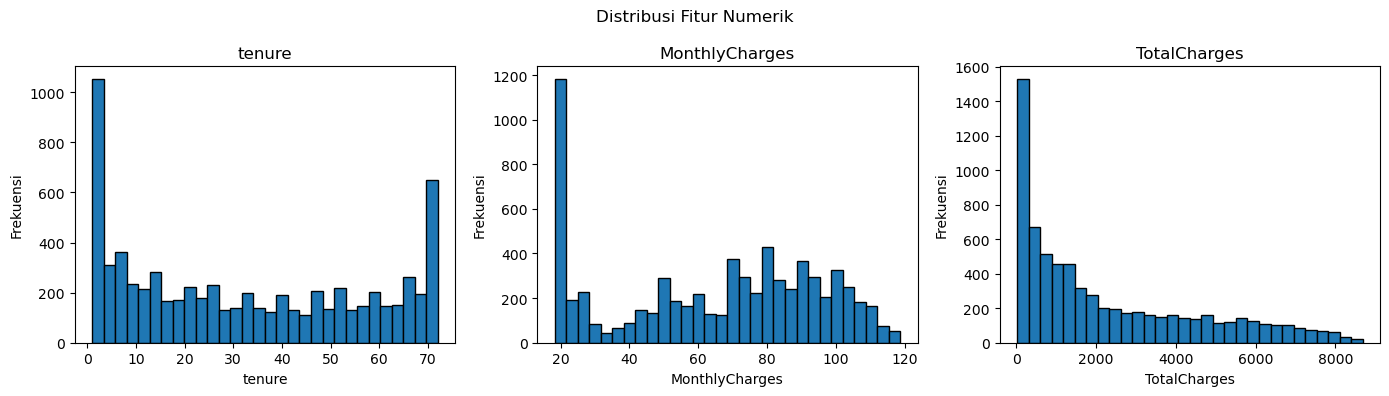

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax.hist(df[col], bins=30, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

Berdasarkan histogram, kolom `tenure` memiliki distribusi yang relatif merata (bimodal), `MonthlyCharges` cukup merata, sedangkan `TotalCharges` condong ke kanan (right-skewed). Karena terdapat distribusi yang tidak normal dan kemungkinan outlier pada `TotalCharges`.
*RobustScaler* karena scaler ini menggunakan median dan IQR sehingga lebih tahan terhadap outlier dibandingkan StandardScaler maupun MinMaxScaler.

In [ ]:
X_num = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_num, y, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_n)
X_test_scaled  = scaler.transform(X_test_n)

X_all_scaled = scaler.fit_transform(X_num) 
model_scaled = LogisticRegression(max_iter=1000)
cv_scaled = cross_val_score(model_scaled, X_all_scaled, y, cv=5, scoring='accuracy')

print(f'CV Accuracy Setelah Scaling — Mean: {cv_scaled.mean():.4f}, Std: {cv_scaled.std():.4f}')

CV Accuracy Setelah Scaling — Mean: 0.7853, Std: 0.0069


Skor CV setelah scaling sedikit berubah dibandingkan baseline, yang menunjukkan bahwa Logistic Regression cukup sensitif terhadap skala fitur. Penerapan RobustScaler membantu model konvergen lebih baik dan menghasilkan bobot yang lebih seimbang antar fitur.


Ordinal -> punya urutan natural:
- `Contract` (Month-to-month < One year < Two year)

Nominal -> tidak punya urutan:
- `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaperlessBilling`, `PaymentMethod`

In [ ]:
df_enc = df.copy()

contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_enc['Contract'] = df_enc['Contract'].map(contract_order)

df_enc = pd.get_dummies(df_enc, columns=['InternetService', 'PaymentMethod'], drop_first=True)

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    unique_vals = df_enc[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    df_enc[col] = df_enc[col].map(mapping)

remaining_cat = df_enc.select_dtypes(include='object').columns.tolist()
if remaining_cat:
    df_enc = pd.get_dummies(df_enc, columns=remaining_cat, drop_first=True)

print('Shape setelah encoding:', df_enc.shape)

Shape setelah encoding: (7032, 30)


D:\Users\bsi80274\AppData\Local\Temp\ipykernel_28908\304882266.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df_enc.select_dtypes(include='object').columns.tolist()


In [ ]:
y = df_enc['Churn']
X_final = df_enc.drop(columns=['Churn'])

num_cols_final = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler2 = RobustScaler()
X_final[num_cols_final] = scaler2.fit_transform(X_final[num_cols_final])

model_enc = LogisticRegression(max_iter=1000)
cv_enc = cross_val_score(model_enc, X_final, y, cv=5, scoring='accuracy')

print(f'CV Accuracy Setelah Scaling + Encoding — Mean: {cv_enc.mean():.4f}, Std: {cv_enc.std():.4f}')

CV Accuracy Setelah Scaling + Encoding — Mean: 0.8038, Std: 0.0073


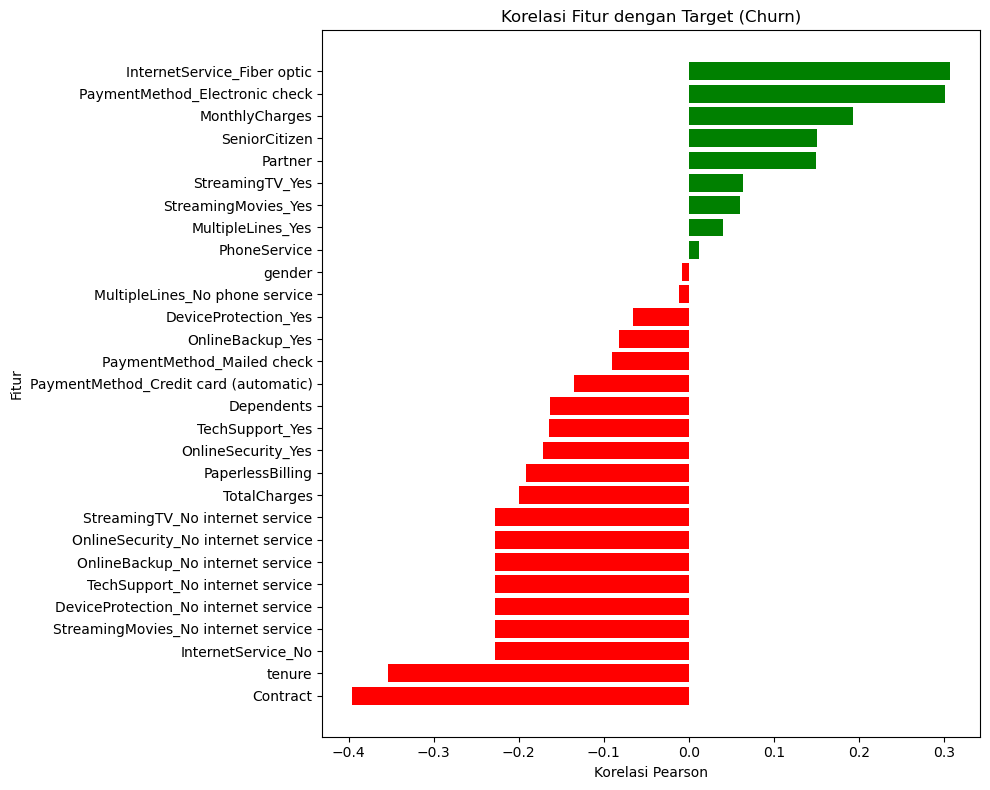

In [ ]:
# Hitung korelasi Pearson setiap fitur dengan target
corr_with_target = X_final.corrwith(y).sort_values()

# Bar chart
colors = ['green' if v > 0 else 'red' for v in corr_with_target.values]

plt.figure(figsize=(10, 8))
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.title('Korelasi Fitur dengan Target (Churn)')
plt.xlabel('Korelasi Pearson')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [ ]:
selected_features = corr_with_target[corr_with_target.abs() > 0.10].index.tolist()
print('Fitur terpilih:', selected_features)

X_selected = X_final[selected_features]

model_sel = LogisticRegression(max_iter=1000)
cv_sel = cross_val_score(model_sel, X_selected, y, cv=5, scoring='accuracy')

print(f'CV Accuracy Setelah Feature Selection — Mean: {cv_sel.mean():.4f}, Std: {cv_sel.std():.4f}')

Fitur terpilih: ['Contract', 'tenure', 'InternetService_No', 'StreamingMovies_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'OnlineBackup_No internet service', 'OnlineSecurity_No internet service', 'StreamingTV_No internet service', 'TotalCharges', 'PaperlessBilling', 'OnlineSecurity_Yes', 'TechSupport_Yes', 'Dependents', 'PaymentMethod_Credit card (automatic)', 'Partner', 'SeniorCitizen', 'MonthlyCharges', 'PaymentMethod_Electronic check', 'InternetService_Fiber optic']
CV Accuracy Setelah Feature Selection — Mean: 0.8023, Std: 0.0087




| Eksperimen                         | CV Accuracy (Mean) | CV Accuracy (Std) |
|------------------------------------|--------------------|-----------------|
| Baseline (numerik saja)            |   0.7851           | 0.0070          |
| Setelah Scaling                    |   0.7853           | 0.00697032      |
| Setelah Scaling + Encoding         |   0.8038           | 0.007           |
| Setelah Feature Selection          |   0.8023           | 0.0087          |


### Kesimpulan

Teknik yang paling berdampak pada skor CV adalah penambahan fitur kategorikal melalui encoding, karena fitur seperti Contract dan InternetService memiliki hubungan kuat dengan perilaku churn pelanggan. Scaling membantu Logistic Regression konvergen lebih cepat dan memberikan bobot yang lebih stabil, namun dampaknya pada akurasi tidak sebesar penambahan fitur baru. Feature selection berbasis korelasi membantu menyederhanakan model tanpa kehilangan banyak informasi penting, sehingga model menjadi lebih efisien dan lebih mudah diinterpretasikan.